# 篇末综合 噪声概率更新与信息的综合实验

## 学习目标与先修知识

能在统一细胞观测（observation）案例中组织重复、分开噪声贡献、更新概率（probability）与传播分布（distribution），并依据有限样本限制信息量结论。

先修：本篇 5.1—5.5 的概率、中心矩、条件更新、马尔可夫（Markov）模型（model）和信息量。 [复习上一节](../05-熵、互信息与测量价值/02-有限样本分箱与信息偏差.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

某理想细胞状态（state）会切换，读数含误差，个体还可能固定地不同。得到更多读数是否就一定意味着更精确的状态、更可靠的因果解释？将每个子问题的假设分开核对。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
display(Markdown(show_table(['子问题','对象','验证基准'],[['重复','实验组均值','分母与组间波动'],['动态','状态与观测方差','独立扰动几何和'],['更新','条件分布','联合概率归一化'],['信息','分箱标签','独立通道与有限样本参照']])) )

| 子问题 | 对象 | 验证基准 |
| --- | --- | --- |
| 重复 | 实验组均值 | 分母与组间波动 |
| 动态 | 状态与观测方差 | 独立扰动几何和 |
| 更新 | 条件分布 | 联合概率归一化 |
| 信息 | 分箱标签 | 独立通道与有限样本参照 |

## 模型假设

综合题分别研究连续偏差和离散细胞标签：前者用有单位的数值描述，后者用类别概率描述。各题给出自己的输入（input）、参数（parameter）和独立性条件，可以分别作答。

## 数学解释与推导

将研究问题拆成可检查的量：

1. 每组先取均值，再用 B−1 分母衡量重复间波动，不能把较大的组悄悄赋予更大权重。
2. 对独立过程扰动，P[n+1]=a²P[n]+Q；独立测量误差给出 S[n]=P[n]+R。测量数增多是否有效，还取决于是否共享偏移。
3. 已有标签先验（prior）乘观测似然（likelihood）后归一化；证据/边际似然（evidence or marginal likelihood）为零保留未定义分支。未来分布用行向量（vector） pP 推进，两步的作用不同。
4. 信息指标对分箱（binning）后的联合表计算。比较嵌套编码时同时保留原始样本量和有限重复参照；I>0 不给出作用方向。

这四层分别检查实验组织、机制位置、概率条件和解释范围。题组按基础辨析、方法应用、综合验证、迁移挑战递进；每题输入完整，不依赖上一题的提交结果。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def repeated_summary(groups):
    means = [sum(g)/len(g) for g in groups]
    overall = sum(means)/len(means)
    variance = sum((x-overall)**2 for x in means)/(len(means)-1)
    return means, overall, variance


def variance_path(a, process_variance, initial_variance, steps):
    values = [initial_variance]
    for _ in range(steps):
        values.append(a*a*values[-1]+process_variance)
    return values


def observed_variances(a, process_variance, measurement_variance, initial_variance, steps):
    state = variance_path(a,process_variance,initial_variance,steps)
    return state, [p+measurement_variance for p in state]


def discrete_update(prior, likelihood):
    weights = [p*l for p,l in zip(prior,likelihood)]
    evidence = sum(weights)
    if evidence == 0:
        return None
    return [w/evidence for w in weights]


def propagate(matrix, initial, steps):
    values = [list(initial)]
    for _ in range(steps):
        current = values[-1]
        values.append([sum(current[i]*matrix[i][j] for i in range(len(current))) for j in range(len(current))])
    return values


def information(counts):
    import math
    total = sum(map(sum, counts))
    joint = [[c/total for c in row] for row in counts]
    px = list(map(sum,joint))
    py = [sum(row[j] for row in joint) for j in range(len(joint[0]))]
    hx = -sum(p*math.log2(p) for p in px if p>0)
    hy = -sum(p*math.log2(p) for p in py if p>0)
    mi = sum(p*math.log2(p/(px[i]*py[j])) for i,row in enumerate(joint) for j,p in enumerate(row) if p>0)
    return hx, hy, mi


def compare_information(coarse_counts, fine_counts):
    return information(coarse_counts), information(fine_counts)

## 对照实验

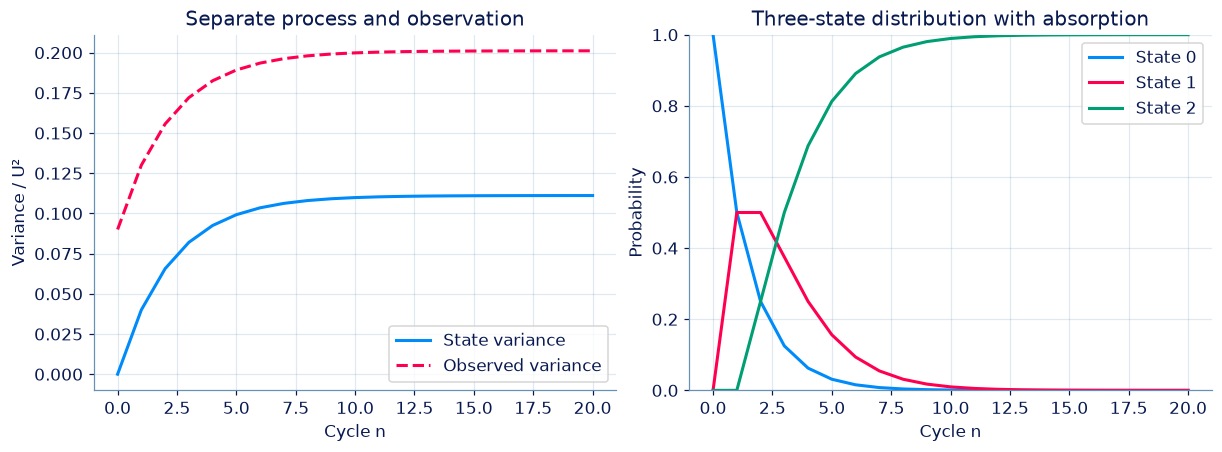

组均值、组平均、组间方差： [1.0, 3.0, 5.0] 3.0 4.0
一次观测后的后验： [0.25, 0.7499999999999999, 0.0]


In [4]:
means,overall,spread=repeated_summary([[0,2],[2,4],[4,6]])
state,observed=observed_variances(.8,.04,.09,0,20)
posterior=discrete_update([.2,.3,.5],[.5,1,0])
P=[[.5,.5,0],[0,.5,.5],[0,0,1]];distributions=np.array(propagate(P,[1,0,0],20))
fig,axes=plt.subplots(1,2,figsize=(11,4));n=np.arange(21)
axes[0].plot(n,state,color=BLUE,label='State variance');axes[0].plot(n,observed,color=PINK,ls='--',label='Observed variance')
axes[0].set(xlabel='Cycle n',ylabel='Variance / U²',title='Separate process and observation');axes[0].legend()
for i,color in enumerate([BLUE,PINK,GREEN]):axes[1].plot(n,distributions[:,i],color=color,label=f'State {i}')
axes[1].set(xlabel='Cycle n',ylabel='Probability',ylim=(0,1),title='Three-state distribution with absorption');axes[1].legend()
plt.show()
print('组均值、组平均、组间方差：',means,overall,spread)
print('一次观测后的后验：',posterior)

## 结果解释

左图比较的是同一偏差模型中两个方差（variance）；右图传播的是另一种有限标签的概率。各自的单位和条件保持独立。增加测量次数影响估计波动，推进时间步改变状态分布，细化分箱改变编码；应分别比较它们带来的变化。

### 独立核对

用手算组统计、前两步分布、固定方差差值和独立联合表核验各子模型，不因组合在同一图中而跳过各自条件。

In [5]:
np.testing.assert_allclose([overall,spread],[3,4])
np.testing.assert_allclose(np.array(observed)-state,.09)
np.testing.assert_allclose(posterior,[.25,.75,0])
np.testing.assert_allclose(distributions[:3],[[1,0,0],[.5,.5,0],[.25,.5,.25]])
np.testing.assert_allclose(distributions.sum(axis=1),1)
assert discrete_update([1,0],[0,1]) is None
np.testing.assert_allclose(information([[1,1],[1,1]]),[1,1,0])
print('独立手算、观测方差贡献、归一化和信息零值基准均通过。')

独立手算、观测方差贡献、归一化和信息零值基准均通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：噪声进入何处

固定 θ 的测量 yᵢ=θ+b+vᵢ，组内 b 固定；动态偏差 x[n+1]=a*x[n]+w[n]。哪些机制解释正确？

- **A.** 同组固定 b 可通过无限次独立 v 测量完全平均掉。
- **B.** 不同个体固定 a 是个体差异。
- **C.** w 改变后续状态（state）。
- **D.** v 在该模型（model）中只改变读数。

[作答：噪声进入何处](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-noise)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：重复实验的比较单位

比较噪声机制，哪项最合适？

- **A.** 把每条时间相关路径中的点全部称为独立个体。
- **B.** 用同一数组（array）复制成 200 组，报告标准误（standard error）为零。
- **C.** 每个机制固定样本量，使用派生随机流做 200 次重复，报告统计量（statistic）的分布（distribution）。
- **D.** 每个机制挑最好的一条路径。

[作答：重复实验的比较单位](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-repeat)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：固定样本的重复间波动

每组是一轮独立测量实验，组内给出实际读数。按组等权汇总均值，并用 B−1 分母计算这些组均值的样本方差（variance）。

**函数与代码模板**

```python
def solve(
    groups: list[list[float]],
) -> tuple[list[float], float, float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `groups` | `list[list[float]]` | B 组测量，每组非空；数值单位 U。 | U |

**返回值**

按以下顺序返回元组：(means, mean_of_means, between_variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 各组均值。 | U |
| `mean_of_means` | `float` | 组均值的等权平均。 | U |
| `between_variance` | `float` | 组均值的样本方差，分母 B−1。 | U² |

**计算规则**

先算组内算术平均，再对 B 个均值求平均和平方偏差和/(B−1)。不改成合并全部读数的统计量（statistic）。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 2≤B≤20；每组 1—100 个读数，绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| groups | B 组测量，每组非空；数值单位 U。 | [[0, 2], [2, 4], [4, 6]] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
groups = [[0, 2], [2, 4], [4, 6]]

result = solve(groups)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 各组均值。 | [1.0, 3.0, 5.0] | U |
| mean_of_means | 组均值的等权平均。 | 3 | U |
| between_variance | 组均值的样本方差，分母 B−1。 | 4 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 3.0, 5.0], 3.0, 4.0)
```

**样例解释**

组均值 [1,3,5]，组平均 3，组间方差 (4+0+4)/2=4 U²。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：固定样本的重复间波动](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-summary)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：由新证据更新概率

三个或更多候选细胞状态（state）中有些先验（prior）可能为零。依据一次离散观测（observation）更新分布（distribution），并显式保留零证据边界。

**函数与代码模板**

```python
def solve(
    prior: list[float],
    likelihood: list[float],
) -> list[float] | None:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior` | `list[float]` | 互斥且穷尽假设的先验概率（probability）。 | 1 |
| `likelihood` | `list[float]` | 同一离散观测在各假设下出现的概率。 | 1 |

**返回值**

直接返回 posterior（list[float] | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `posterior` | <code>list[float] &#124; None</code> | 按原顺序返回后验（posterior）；证据/边际似然（evidence or marginal likelihood）为零时返回 None。 | 1 |

**计算规则**

weights[i]=prior[i]*likelihood[i]；分母为 weights 之和。分母>0 时逐项归一化；分母恰为 0 返回 None，不杜撰均匀后验。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 列表等长，长度 1—20；prior 非负且和为 1（误差≤1e−12）；likelihood 每项在 [0,1]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior | 互斥且穷尽假设的先验概率（probability）。 | [0.2, 0.3, 0.5] | 1 |
| likelihood | 同一离散观测在各假设下出现的概率。 | [0.5, 1, 0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior = [0.2, 0.3, 0.5]
likelihood = [0.5, 1, 0]

result = solve(prior, likelihood)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| posterior | 按原顺序返回后验（posterior）；证据/边际似然（evidence or marginal likelihood）为零时返回 None。 | [0.25, 0.7499999999999999, 0.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.25, 0.7499999999999999, 0.0]
```

**样例解释**

权重 [0.1,0.3,0]，后验 [0.25,0.75,0]；此次观测排除第三态。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：由新证据更新概率](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-bayes)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：概率分布的多步传播

理想细胞有三个标签，允许吸收标签。按完整转移矩阵（transition matrix）传播群体分布（distribution），保持行向量（vector）约定。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    initial: list[float],
    steps: int,
) -> list[list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 行随机矩阵（matrix）；第 i 行给出从状态（state） i 到各状态的概率（probability）。 | 1 |
| `initial` | `list[float]` | 时刻 0 的行概率向量。 | 1 |
| `steps` | `int` | 传播步数。 | 步 |

**返回值**

直接返回 distributions（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `distributions` | `list[list[float]]` | 包含时刻 0，外层按时刻，内层按状态编号。 | 1 |

**计算规则**

p_next[j]=Σᵢp[i]*matrix[i][j]；同步更新所有分量；包含初始分布。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 方阵维数 1—5；非负且每行和为 1（误差≤1e−12）；initial 等维、非负、和为 1；0≤steps≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 行随机矩阵（matrix）；第 i 行给出从状态（state） i 到各状态的概率（probability）。 | [[0.5, 0.5, 0], [0, 0.5, 0.5], [0, 0, 1]] | 1 |
| initial | 时刻 0 的行概率向量。 | [1, 0, 0] | 1 |
| steps | 传播步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[0.5, 0.5, 0], [0, 0.5, 0.5], [0, 0, 1]]
initial = [1, 0, 0]
steps = 2

result = solve(matrix, initial, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| distributions | 包含时刻 0，外层按时刻，内层按状态编号。 | [[1, 0, 0], [0.5, 0.5, 0.0], [0.25, 0.5, 0.25]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1, 0, 0],
                   [0.5, 0.5, 0.0],
                   [0.25, 0.5, 0.25]]
```

**样例解释**

从 [1,0,0] 到 [0.5,0.5,0]，再到 [0.25,0.5,0.25]；最后状态吸收进入的概率质量（probability mass）。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：概率分布的多步传播](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-propagation)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：两种噪声的方差贡献

动态偏差 x[n+1]=a*x[n]+w[n]，观测（observation） y[n]=x[n]+v[n]。过程与测量扰动相互独立，也与适当时刻状态（state）独立，方差（variance）固定。分别输出（output）状态与观测方差。

**函数与代码模板**

```python
def solve(
    a: float,
    process_variance: float,
    measurement_variance: float,
    initial_variance: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 每步状态偏差的倍数。 | 1 |
| `process_variance` | `float` | 独立过程扰动方差 Q。 | U² |
| `measurement_variance` | `float` | 每次独立测量误差方差 R。 | U² |
| `initial_variance` | `float` | 起始状态偏差方差 P0。 | U² |
| `steps` | `int` | 更新步数。 | 步 |

**返回值**

按以下顺序返回元组：(state_variances, observation_variances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state_variances` | `list[float]` | 包含起点的状态方差。 | U² |
| `observation_variances` | `list[float]` | 与时刻一一对应的观测方差。 | U² |

**计算规则**

P[0]=initial_variance，P[n+1]=a²P[n]+Q；每个时刻观测方差 S[n]=P[n]+R。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- −1≤a≤1；三种给定方差在 [0,10]；0≤steps≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 每步状态偏差的倍数。 | 0.8 | 1 |
| process_variance | 独立过程扰动方差 Q。 | 0.04 | U² |
| measurement_variance | 每次独立测量误差方差 R。 | 0.09 | U² |
| initial_variance | 起始状态偏差方差 P0。 | 0 | U² |
| steps | 更新步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.8
process_variance = 0.04
measurement_variance = 0.09
initial_variance = 0
steps = 2

result = solve(a, process_variance, measurement_variance, initial_variance, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| state_variances | 包含起点的状态方差。 | [0, 0.04, 0.0656] | U² |
| observation_variances | 与时刻一一对应的观测方差。 | [0.09, 0.13, 0.15560000000000002] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 0.04, 0.0656],
                   [0.09, 0.13, 0.15560000000000002])
```

**样例解释**

Q=0.04，R=0.09，a=0.8 时：状态 [0,0.04,0.0656]；观测 [0.09,0.13,0.1556] U²。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：两种噪声的方差贡献](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-variance)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：更换分箱后的信息量

同一批配对读数以两种嵌套分箱（binning）形成粗、细联合计数。分别计算信息指标，比较对象是两个离散编码。

**函数与代码模板**

```python
def solve(
    coarse_counts: list[list[int]],
    fine_counts: list[list[int]],
) -> tuple[list[float], list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coarse_counts` | `list[list[int]]` | 粗分箱联合计数。 | 次 |
| `fine_counts` | `list[list[int]]` | 细分箱联合计数；与粗表总数一致。 | 次 |

**返回值**

按以下顺序返回元组：(coarse_information, fine_information)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coarse_information` | `list[float]` | 依次为粗表的 H(X)、H(Y)、I(X;Y)。 | bit |
| `fine_information` | `list[float]` | 依次为细表的 H(X)、H(Y)、I(X;Y)。 | bit |

**计算规则**

先除以总频数得到 p[i,j]，按行列求边缘概率（probability）；H(X)=−ΣpX log2(pX)，H(Y) 同理；I=Σp[i,j] log2(p[i,j]/(pX[i]*pY[j]))。零概率项贡献 0，不给零频数加伪计数。分别对两个表计算，返回两组三元结果；不报告因果效应。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 两表各满足矩形非负整数、总频数>0；各边长 1—8，每项≤10000；粗表可由细表合并相邻行列得到。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| coarse_counts | 粗分箱联合计数。 | [[2, 2], [2, 2]] | 次 |
| fine_counts | 细分箱联合计数；与粗表总数一致。 | [[1, 0, 1, 0], [0, 1, 0, 1], [1, 0, 1, 0], [0, 1, 0, 1]] | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
coarse_counts = [[2, 2], [2, 2]]
fine_counts = [[1, 0, 1, 0],
               [0, 1, 0, 1],
               [1, 0, 1, 0],
               [0, 1, 0, 1]]

result = solve(coarse_counts, fine_counts)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coarse_information | 依次为粗表的 H(X)、H(Y)、I(X;Y)。 | [1.0, 1.0, 0.0] | bit |
| fine_information | 依次为细表的 H(X)、H(Y)、I(X;Y)。 | [2.0, 2.0, 1.0] | bit |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.0, 0.0], [2.0, 2.0, 1.0])
```

**样例解释**

粗表独立，结果 [1,1,0]；细表各边缘熵（entropy） 2 bit，互信息（mutual information） 1 bit，结果 [2,2,1]。细分暴露关联，也可能更受有限样本偏差影响。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：更换分箱后的信息量](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-bins)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：观测价值与因果范围

独立通道的小样本插件互信息（mutual information）偏正；细分后更大；重复实验显示相当波动。哪些结论可支持？

- **A.** 最大一次互信息即可证明因果效应。
- **B.** 报告有限样本参照和波动，保留共同原因解释。
- **C.** 增加分箱（binning）必能提高真实测量质量。
- **D.** 固定样本量、分箱与重复设计后再比较通道。

[作答：观测价值与因果范围](http://127.0.0.1:8000/parts/05-%E9%9A%8F%E6%9C%BA%E6%80%A7%E4%B8%8E%E4%BF%A1%E6%81%AF/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p05-cap-scope)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：本篇涉及的概率与过程主题。

[MIT 6.441 讲义](https://ocw.mit.edu/courses/6-441-information-theory-spring-2016/pages/lecture-notes/)，第 1 章 §1.1 熵、第 2 章 §2.3 互信息、第 3 章 §3.1 数据处理。